In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("beauty_clean.csv")

In [4]:
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (51290, 19)


In [5]:
df.head()

,Row ID,Order ID,Order Date,Customer ID,Segment,City,State,Country,Country latitude,Country longitude,Region,Market,Subcategory,Category,Product,Quantity,Sales,Discount,Profit
0,25221,IN-2012-TH211151-41003,2020-04-04,TH-211151,Corporate,Jalalabad,Nangarhar,Afghanistan,33.93911,67.709953,Southern Asia,Asia Pacific,"bath oils, bubbles and soaks",Body care,Soap & Glory Endless Glove Moisturizing Hand C...,13,416,0.0,208.0
1,25220,IN-2012-TH211151-41003,2020-04-04,TH-211151,Corporate,Jalalabad,Nangarhar,Afghanistan,33.93911,67.709953,Southern Asia,Asia Pacific,hand creams,Body care,MAC ColorStay Foundation,5,70,0.0,35.0
2,25218,IN-2012-TH211151-41003,2020-04-04,TH-211151,Corporate,Jalalabad,Nangarhar,Afghanistan,33.93911,67.709953,Southern Asia,Asia Pacific,Nail care products,Body care,Eucerin Advanced Repair Cream,18,216,0.0,108.0
3,25217,IN-2012-TH211151-41003,2020-04-04,TH-211151,Corporate,Jalalabad,Nangarhar,Afghanistan,33.93911,67.709953,Southern Asia,Asia Pacific,"candles, sprays, diffusers",Home and Accessories,Diptyque French Cade Lavender Candle,12,132,0.0,13.2
4,25219,IN-2012-TH211151-41003,2020-04-04,TH-211151,Corporate,Jalalabad,Nangarhar,Afghanistan,33.93911,67.709953,Southern Asia,Asia Pacific,Eye shadows and pencils,Make up,NARS Single Eyeshadow Persia Matte Paprika,2,34,0.0,17.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Row ID             51290 non-null  int64  
 1   Order ID           51290 non-null  object 
 2   Order Date         51290 non-null  object 
 3   Customer ID        51290 non-null  object 
 4   Segment            51290 non-null  object 
 5   City               51290 non-null  object 
 6   State              51290 non-null  object 
 7   Country            51290 non-null  object 
 8   Country latitude   51290 non-null  float64
 9   Country longitude  51290 non-null  float64
 10  Region             51290 non-null  object 
 11  Market             51290 non-null  object 
 12  Subcategory        51290 non-null  object 
 13  Category           51290 non-null  object 
 14  Product            51290 non-null  object 
 15  Quantity           51290 non-null  int64  
 16  Sales              512

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,51290.0,NaN,NaN,NaN,25645.5,14806.29199,1.0,12823.25,25645.5,38467.75,51290.0
Order ID,51290,25728,CA-2015-SV20365140-42268,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,51290,1430,2023-06-18,135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,51290,17415,SV-203651406,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,51290,3,Consumer,26518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,51290,3650,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,51290,1102,California,2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,51290,164,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country latitude,51290.0,NaN,NaN,NaN,24.506298,24.119393,-40.900557,12.879721,35.86166,38.963745,61.92411
Country longitude,51290.0,NaN,NaN,NaN,-4.585665,80.298692,-106.346771,-95.712891,2.213749,43.679291,174.885971


In [8]:
print("Columns:")
for col in df.columns:
    print(col)

Columns:
Row ID
Order ID
Order Date
Customer ID
Segment
City
State
Country
Country latitude
Country longitude
Region
Market
Subcategory
Category
Product
Quantity
Sales
Discount
Profit


In [9]:
missing_values = df.isnull().sum()

print(missing_values)

Row ID               0
Order ID             0
Order Date           0
Customer ID          0
Segment              0
City                 0
State                0
Country              0
Country latitude     0
Country longitude    0
Region               0
Market               0
Subcategory          0
Category             0
Product              0
Quantity             0
Sales                0
Discount             0
Profit               0
dtype: int64


In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary

,Missing Values,Missing Percentage
Row ID,0,0.0
Order ID,0,0.0
Order Date,0,0.0
Customer ID,0,0.0
Segment,0,0.0
City,0,0.0
State,0,0.0
Country,0,0.0
Country latitude,0,0.0
Country longitude,0,0.0


In [11]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [12]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (51290, 19)


In [13]:
print(df["Order Date"].dtype)

object


In [14]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    errors="coerce"
)

print(df["Order Date"].dtype)

datetime64[ns]


In [15]:
print("Invalid dates:", df["Order Date"].isna().sum())

Invalid dates: 0


In [16]:
numeric_columns = [
    "Quantity",
    "Sales",
    "Discount",
    "Profit"
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,51290.0,5.415832,4.908234,1.0,2.0,4.0,7.0,20.00
Sales,51290.0,127.074946,236.074764,2.0,25.0,56.0,132.0,3940.00
Discount,51290.0,0.142908,0.212280,0.0,0.0,0.0,0.2,0.85
Profit,51290.0,20.772346,83.582680,-1746.0,0.0,7.2,25.0,1820.00


In [17]:
print("Invalid Quantity:", (df["Quantity"] <= 0).sum())

print("Invalid Sales:", (df["Sales"] < 0).sum())

print("Discount below 0:", (df["Discount"] < 0).sum())

print("Discount above 1:", (df["Discount"] > 1).sum())

print("Negative Profit:", (df["Profit"] < 0).sum())

Invalid Quantity: 0
Invalid Sales: 0
Discount below 0: 0
Discount above 1: 0
Negative Profit: 11041


In [18]:
categorical_columns = [
    "Segment",
    "Country",
    "Region",
    "Market",
    "Subcategory",
    "Category"
]

for col in categorical_columns:
    print("\n====================")
    print("Column:", col)
    print("Unique values:", df[col].nunique())
    print(df[col].unique()[:30])


Column: Segment
Unique values: 3
['Corporate' 'Consumer' 'Self-Employed']

Column: Country
Unique values: 164
['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Bahrain' 'Bangladesh' 'Barbados'
 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bhutan' 'Bolivia'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Bulgaria' 'Burkina Faso'
 'Burundi' 'Cambodia' 'Cameroon' 'Canada' 'Central African Republic'
 'Chad' 'Chile']

Column: Region
Unique values: 23
['Southern Asia' 'Southern Europe' 'North Africa' 'Central Africa'
 'South America' 'Western Asia' 'Oceania' 'Western Europe' 'Caribbean'
 'Eastern Europe' 'Central America' 'Western Africa' 'Southern Africa'
 'Eastern Africa' 'Southeastern Asia' 'Canada' 'Eastern Asia'
 'Northern Europe' 'Central Asia' 'Central US' 'Eastern US' 'Southern US'
 'Western US']

Column: Market
Unique values: 5
['Asia Pacific' 'Europe' 'Africa' 'LATAM' 'USCA']

Column: Subcategory
Unique values: 17
['bath oils, bubbles a

In [19]:
for col in categorical_columns:
    df[col] = df[col].astype(str).str.strip()

In [20]:
for col in categorical_columns:
    print(col, ":", df[col].nunique())

Segment : 3
Country : 164
Region : 23
Market : 5
Subcategory : 17
Category : 5


In [21]:
df["Category"] = df["Category"].str.lower()

In [22]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return outliers, lower_bound, upper_bound

In [23]:
for col in ["Quantity", "Sales", "Discount", "Profit"]:

    outliers, lower, upper = detect_outliers_iqr(df, col)

    print("\n====================")
    print("Column:", col)
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Outlier Count:", len(outliers))


Column: Quantity
Lower Bound: -5.5
Upper Bound: 14.5
Outlier Count: 4604

Column: Sales
Lower Bound: -135.5
Upper Bound: 292.5
Outlier Count: 5126

Column: Discount
Lower Bound: -0.30000000000000004
Upper Bound: 0.5
Outlier Count: 4172

Column: Profit
Lower Bound: -37.5
Upper Bound: 62.5
Outlier Count: 7740


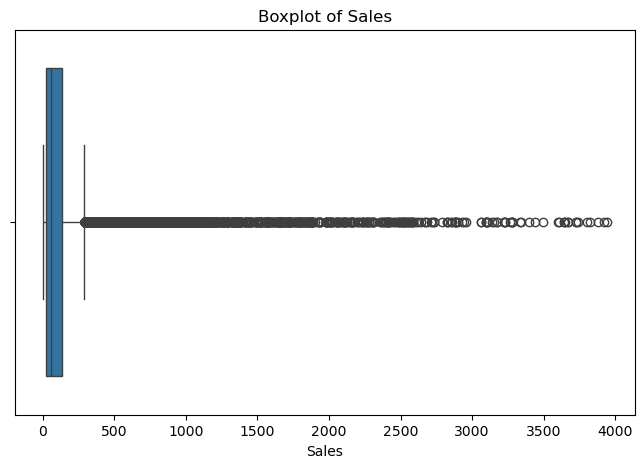

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Sales"])

plt.title("Boxplot of Sales")
plt.xlabel("Sales")

plt.show()

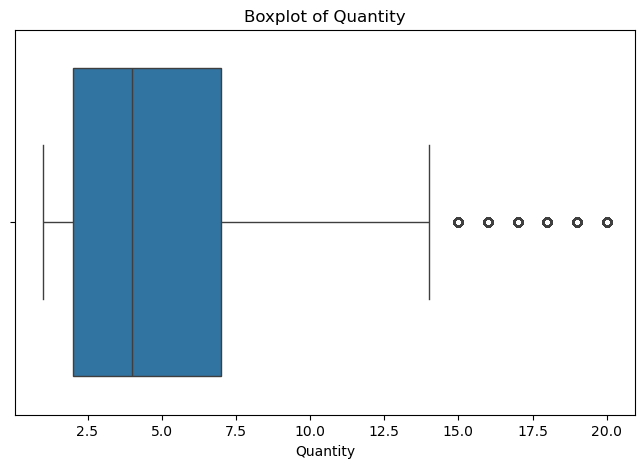

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Quantity"])

plt.title("Boxplot of Quantity")
plt.xlabel("Quantity")

plt.show()

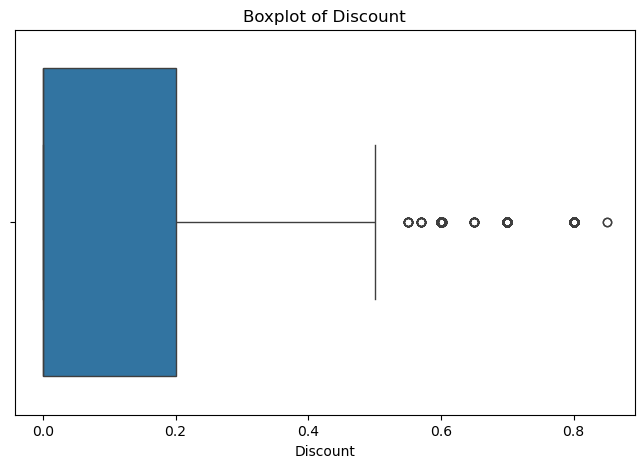

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Discount"])

plt.title("Boxplot of Discount")
plt.xlabel("Discount")

plt.show()

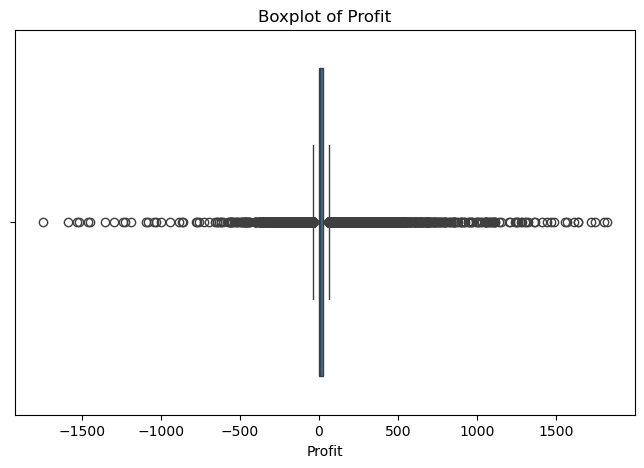

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Profit"])

plt.title("Boxplot of Profit")
plt.xlabel("Profit")

plt.show()

In [28]:
print("Highest Sales:")
print(df[["Order ID", "Product", "Sales"]]
      .sort_values("Sales", ascending=False)
      .head(10))

Highest Sales:
                       Order ID                     Product  Sales
16097   ES-2013-MC1760548-41471       Ruby Whisper Bracelet   3940
17274   IT-2015-HK1489048-42243     Silver Glimmer Necklace   3920
38339   TU-2015-RR9525134-42280         Sterling Frost Ring   3880
45395  CA-2014-KB16600140-41796     Golden Feather Earrings   3820
39347  IT-2013-JR16210139-41468         Silver Embrace Ring   3800
6017    MX-2015-HK1489018-42326       Ruby Whisper Bracelet   3743
20869   ID-2012-MS1798059-41234     Silver Glimmer Necklace   3724
27508   MX-2015-ND1846082-42207  Golden Grace Stud Earrings   3724
10728   MX-2013-MF1766536-41535       Silver Gleam Necklace   3667
21442   ID-2014-EB1370559-41853       Golden Blaze Necklace   3667


In [29]:
print("\nHighest Quantity:")
print(df[["Order ID", "Product", "Quantity"]]
      .sort_values("Quantity", ascending=False)
      .head(10))


Highest Quantity:
                       Order ID  \
2430     ID-2014-HH150107-41923   
47468  CA-2015-HW14935140-42056   
47741  CA-2015-BF11020140-42096   
2391     ID-2014-EM140957-41914   
47737  CA-2015-NC18535140-42096   
47692  US-2015-HK14890140-42090   
38201  TU-2015-SC10770134-42185   
38136   TU-2015-BN1470134-42146   
38122  TU-2015-AS10045134-42136   
38117   TU-2015-PJ8835134-42133   

                                                 Product  Quantity  
2430   Dr Hauschka Lemon Lemongrass Vitalising Bath E...        20  
47468             Revlon Nail Enamel Bewitching Deep Red        20  
47741        Maison Margiela French Cade Lavender Candle        20  
2391   Clairol Flare Me Dark Permanent Cream Color - ...        20  
47737                 Fresh Umbrian Clay Mattifying Mask        20  
47692              Vaseline Intensive Care Healing Serum        20  
38201  CeraVe Diabetics' Dry Skin Relief Moisturizing...        20  
38136          L'Occitane Verbena Cooling H

In [30]:
print("\nHighest Discount:")
print(df[["Order ID", "Product", "Discount"]]
      .sort_values("Discount", ascending=False)
      .head(10))


Highest Discount:
                       Order ID  \
16310   IT-2013-MW1823548-41594   
16005   IT-2013-BF1121548-41425   
49404  CA-2015-JK15730140-42285   
48913  US-2015-EP13915140-42251   
48754  CA-2015-ED13885140-42234   
48982  US-2015-BF11020140-42256   
49453  CA-2015-TS21610140-42291   
49465  CA-2015-AG10765140-42292   
49466  CA-2015-AG10765140-42292   
48909  CA-2015-JS15595140-42250   

                                                 Product  Discount  
16310                  Optimum Nutrition Iron Supplement      0.85  
16005                  Redken Extreme Length Conditioner      0.85  
49404                  Kiehl's Ultra Facial Cream SPF 30      0.80  
48913                            Redken All Soft Shampoo      0.80  
48754  Urban Decay Flawless Fusion Ultra-Longwear Fou...      0.80  
48982             Head & Shoulders Classic Clean Shampoo      0.80  
49453                               Gold Spectrum Anklet      0.80  
49465  Dove Nutritive Solutions Anti-Frizz 

In [31]:
print("\nLowest Profit:")
print(df[["Order ID", "Product", "Profit"]]
      .sort_values("Profit")
      .head(10))


Lowest Profit:
                       Order ID                     Product   Profit
38339   TU-2015-RR9525134-42280         Sterling Frost Ring -1746.00
51212    ZA-2012-AH690147-40950  Sterling Elegance Bracelet -1588.40
24771    KZ-2014-KB658568-41998      Amethyst Echo Earrings -1528.80
39347  IT-2013-JR16210139-41468         Silver Embrace Ring -1520.00
28727   ID-2015-PC1874588-42056         Sterling Frost Ring -1458.88
31428    NI-2015-CB253595-42362           Golden Orb Locket -1449.60
21442   ID-2014-EB1370559-41853       Golden Blaze Necklace -1356.79
37579   TU-2013-MK7905134-41619       Silver Frost Bracelet -1299.60
24024   ES-2015-HR1483064-42013    Sterling Solstice Anklet -1238.40
30699    NI-2012-KB660095-41223        Golden Halo Earrings -1229.25


In [32]:
analysis_date = df["Order Date"].max()

customer_df = df.groupby("Customer ID").agg(
    Recency=("Order Date", lambda x: (analysis_date - x.max()).days),
    Frequency=("Order ID", "nunique"),
    Monetary=("Sales", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Total_Profit=("Profit", "sum"),
    Avg_Discount=("Discount", "mean")
).reset_index()

customer_df["Average_Order_Value"] = (
    customer_df["Monetary"] /
    customer_df["Frequency"]
)

print("Customer-level dataset shape:", customer_df.shape)

Customer-level dataset shape: (17415, 8)


In [33]:
customer_df.isnull().sum()

Customer ID            0
Recency                0
Frequency              0
Monetary               0
Total_Quantity         0
Total_Profit           0
Avg_Discount           0
Average_Order_Value    0
dtype: int64

In [34]:
customer_df.duplicated().sum()

np.int64(0)

In [35]:
customer_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,17415.0,507.087913,400.619145,0.0,148.0,421.000,803.00,1460.0
Frequency,17415.0,1.477979,0.852081,1.0,1.0,1.000,2.00,9.0
Monetary,17415.0,374.256331,587.724976,2.0,63.0,170.000,431.00,7351.0
Total_Quantity,17415.0,15.950502,19.629217,1.0,4.0,9.000,19.00,230.0
Total_Profit,17415.0,61.177930,181.245653,-2154.8,1.4,21.600,80.00,2625.3
Avg_Discount,17415.0,0.144607,0.204190,0.0,0.0,0.002,0.24,0.8
Average_Order_Value,17415.0,250.822542,378.898679,2.0,53.9,126.000,290.25,5622.0


In [36]:
customer_df["Activity_Status"] = np.where(
    customer_df["Recency"] <= 365,
    "Active",
    "Inactive"
)

In [37]:
print(customer_df["Activity_Status"].value_counts())

Activity_Status
Inactive    9768
Active      7647
Name: count, dtype: int64


In [38]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "Total_Quantity",
    "Total_Profit",
    "Avg_Discount",
    "Average_Order_Value"
]

In [39]:
from sklearn.preprocessing import StandardScaler

In [40]:
scaler = StandardScaler()

customer_scaled = customer_df.copy()

customer_scaled[features] = scaler.fit_transform(
    customer_scaled[features]
)

In [41]:
customer_scaled[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,17415.0,3.182448e-17,1.000029,-1.265797,-0.896358,-0.214893,0.738658,2.378667
Frequency,17415.0,-4.794072e-17,1.000029,-0.560971,-0.560971,-0.560971,0.612660,8.828075
Monetary,17415.0,2.631640e-17,1.000029,-0.633403,-0.529610,-0.347547,0.096551,11.871103
Total_Quantity,17415.0,-3.345651e-17,1.000029,-0.761667,-0.608829,-0.354100,0.155359,10.904951
Total_Profit,17415.0,3.060046e-17,1.000029,-12.226729,-0.329827,-0.218372,0.103851,14.147626
Avg_Discount,17415.0,5.304080e-17,1.000029,-0.708221,-0.708221,-0.698426,0.467190,3.209818
Average_Order_Value,17415.0,3.916859e-17,1.000029,-0.656718,-0.519738,-0.329445,0.104061,14.176169


In [42]:
print("Transaction Dataset")
print("--------------------")

print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Transaction Dataset
--------------------
Shape: (51290, 19)
Missing values: 0
Duplicate rows: 0


In [43]:
print("\nCustomer Dataset")
print("--------------------")

print("Shape:", customer_df.shape)
print("Missing values:", customer_df.isnull().sum().sum())
print("Duplicate rows:", customer_df.duplicated().sum())


Customer Dataset
--------------------
Shape: (17415, 9)
Missing values: 0
Duplicate rows: 0


In [44]:
print("\nActivity Status")
print("--------------------")
print(customer_df["Activity_Status"].value_counts())


Activity Status
--------------------
Activity_Status
Inactive    9768
Active      7647
Name: count, dtype: int64


In [45]:
df.to_csv(
    "beauty_preprocessed.csv",
    index=False
)

customer_df.to_csv(
    "customer_features_preprocessed.csv",
    index=False
)

customer_scaled.to_csv(
    "customer_features_scaled.csv",
    index=False
)

print("All preprocessed files saved successfully!")

All preprocessed files saved successfully!
